In [21]:
#Step 1: Import Libraries and Load Dataset
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape) #This shape gives us howmany images are there in training/testing dataset,size of this image in pixel(grayscale))
print("Testing data shape:", x_test.shape) #60000,  this means y_train has 60000 labels (one for each img) digits from 0 to 9
print("Training data shape:", y_train.shape) #This shape gives us howmany images are there in training/testing dataset,size of this image in pixel(grayscale))
print("Testing data shape:", y_test.shape)




Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Training data shape: (60000,)
Testing data shape: (10000,)


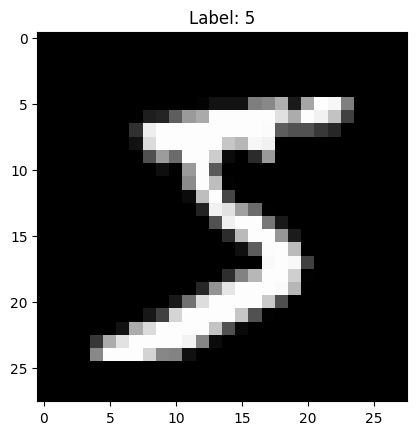

In [22]:
#Checking how the train data and train label looks like
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [23]:
#Step 2: Preprocess the Data
# Normalize (0–255 → 0–1)

print("before normalizing",x_train[0][10][10])
x_train = x_train / 255.0
x_test = x_test / 255.0

print("after normalizing",x_train[0][10][10])

#output of normalizing will in between values 0-1

# Reshape to CNN format (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode labels -10 is the length of vector
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

#output of one-hot encode labels means one vector containing only value as 1 and others as zero

print("Processed shape:", x_train.shape)

before normalizing 1
after normalizing 0.00392156862745098
Processed shape: (60000, 28, 28, 1)


In [24]:
#Step 3: Build the CNN Model
model = keras.models.Sequential([

    # Convolution Layer 1
    #conv2D-->filters =32,size(3*3)
    #maxpooling-->important features only(max value of each superimposition)
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    # Convolution Layer 2
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    # Flatten to get one dimesional output
    keras.layers.Flatten(),

    # Dense Layers-fully connected layer-learns relation between features
    #dropout is dropping 50%of neurons in order to avoid overfitting
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),

    # Output Layer using softmax beacuse output is 10 category(0-9)
    keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
#since we used one-hot encoding to convert y_train labels use 'categorical_crossentropy' as loss to understand diff b/w y pred and y_test

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#Step 4: Train the Model
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.9259 - loss: 0.2431 - val_accuracy: 0.9827 - val_loss: 0.0542
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9742 - loss: 0.0861 - val_accuracy: 0.9897 - val_loss: 0.0365
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9811 - loss: 0.0648 - val_accuracy: 0.9903 - val_loss: 0.0357
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step - accuracy: 0.9852 - loss: 0.0499 - val_accuracy: 0.9910 - val_loss: 0.0332
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9866 - loss: 0.0433 - val_accuracy: 0.9917 - val_loss: 0.0315


In [26]:
#Step 5: Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9923 - loss: 0.0274
Test Accuracy: 0.9922999739646912


In [46]:
from google.colab import files
uploaded = files.upload()

Saving single digit-test.webp to single digit-test (2).webp


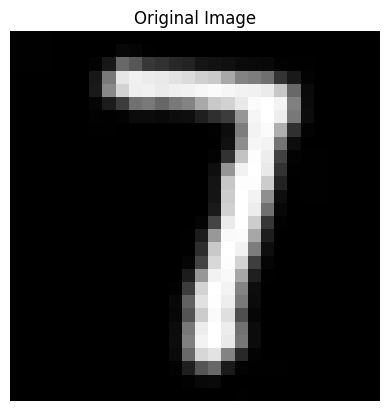

In [47]:
#uploading a mnist style photo
from PIL import Image

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Open image and convert to grayscale
img = Image.open(img_path).convert('L')

# Resize to 28x28 (MNIST format)
img = img.resize((28, 28))

# Convert to numpy array
img_array = np.array(img)

# Show original image
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [48]:
# Normalize (0–255 → 0–1)
img_array = img_array / 255.0

# Reshape to match CNN input
img_array = img_array.reshape(1, 28, 28, 1)

prediction = model.predict(img_array)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Digit: 7


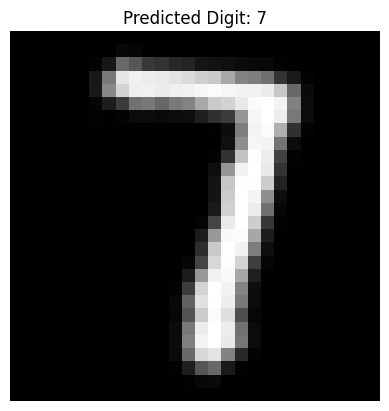

In [49]:
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')
plt.show()

In [34]:
#upload a diffrent image
from google.colab import files
uploaded = files.upload()

Saving white background-test.webp to white background-test (2).webp


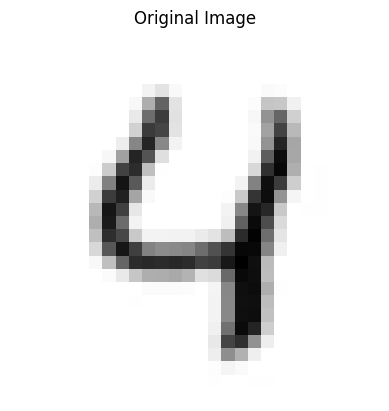

In [42]:
from PIL import Image

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Open image and convert to grayscale
img = Image.open(img_path).convert('L')

# Resize to 28x28 (MNIST format)
img = img.resize((28, 28))

# Convert to numpy array
img_array = np.array(img)

# Show original image
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [43]:
# Invert image colors
img_array = 255 - img_array
# Normalize (0–255 → 0–1)
img_array = img_array / 255.0

# Reshape to match CNN input
img_array = img_array.reshape(1, 28, 28, 1)
prediction = model.predict(img_array)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

#i used white background,black as font color for this custom image.without inverting image color it is giving output as 1.but when used inverting image color it is giving correct output


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Digit: 4


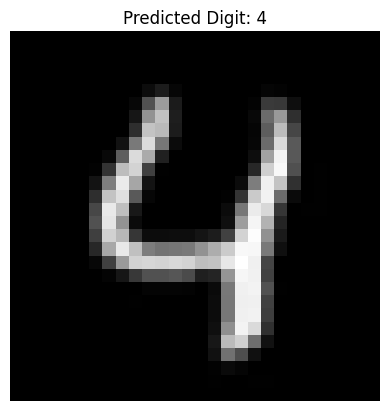

In [44]:
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')
plt.show()